In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
#X=pd.read_csv('nifty.csv')
#len(X)

In [3]:
def data1():
    X=pd.read_csv('tempcnn.csv')
    X = X.iloc[20:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [4]:
X=data1()
print(len(X))

2825


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\IIITNAGPUR\AppData\Roaming\Python\Python312\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


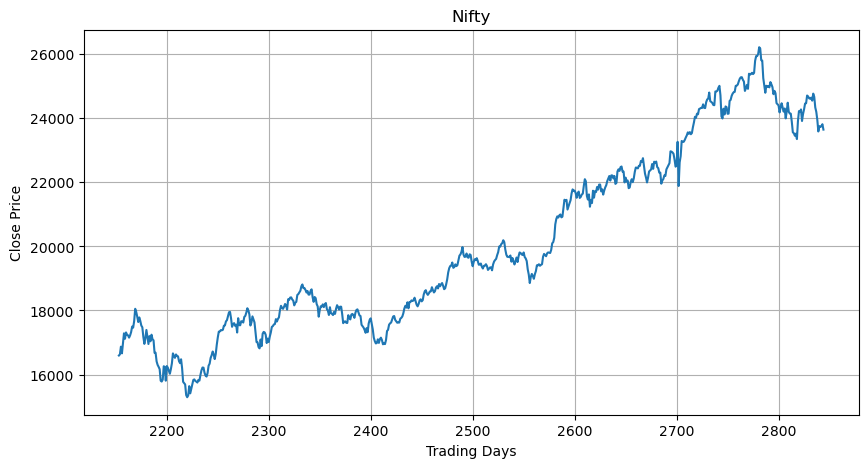

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
%pylab inline
fig = plt.figure()
ax=X.loc[2153:2889,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
len(X)

2825

In [7]:
X['state2d'].value_counts()

state2d
3.0    840
5.0    773
0.0    401
2.0    356
4.0    314
1.0    140
Name: count, dtype: int64

In [8]:
X.head()

,Unnamed: 0,index,Close,High,Low,Open,Volume,date,weekday,month,...,PVT,Target,cnnstate,p_co,state2d,cashopen,cash,action,diff,quantity
20,20,120,5588.700195,5635.250000,5579.350098,5627.950195,160100,26-06-2013,0.50,0.454545,...,0.361818,0,2.0,1.060175,5.0,0.0,0.0,,,
21,21,121,5682.350098,5699.350098,5630.950195,5647.950195,239000,27-06-2013,0.75,0.454545,...,0.368536,2,2.0,1.181728,5.0,0.0,0.0,,,
22,22,122,5842.200195,5852.950195,5749.500000,5749.500000,214400,28-06-2013,1.00,0.454545,...,0.378654,2,2.0,-0.138648,2.0,0.0,0.0,,,
23,23,123,5898.850098,5904.350098,5822.200195,5834.100098,144800,01-07-2013,0.00,0.545455,...,0.381010,2,0.0,-0.226317,0.0,0.0,0.0,,,
24,24,124,5857.549805,5898.799805,5852.299805,5885.500000,145700,02-07-2013,0.25,0.545455,...,0.379298,0,0.0,-0.778476,0.0,0.0,0.0,,,


In [9]:
def getState(t):    
    t = int(t)
    return(X['state2d'][t])  

In [10]:
class Agent:
    def __init__(self):
           
        self.gamma = np.load('rl/gamma100.npy')
        self.Q = np.load('rl/Qtable100.npy')
        self.learning_rate=np.load('rl/learning_rate100.npy')
        self.epsilon = np.load('rl/epsilon100.npy')
        print(self.epsilon)
    def getAction(self,state):
        state = int(state)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [11]:
episode_count=30
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=2107
    data_length=2844
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    X.loc[2,'cashopen']=margin 
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
       
        elif action == 2:
            X.loc[t,'cashopen']=margin 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=margin         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t)
        #print("Next state:", next_state)  # Debugging
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n")
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
       
    
    m3=roi
    if m3>m2:
          m1=e
          m2=m3
        #To save model  
    if e%1==0:
            np.save('rl/test/Qtable'+ str(e)+str('.npy'), agent.Q)
            np.save('rl/test/epsilon'+ str(e)+str('.npy'), agent.epsilon)
            np.save('rl/test/gamma'+ str(e)+str('.npy'), agent.gamma)
            np.save('rl/test/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
            X.to_csv('csv1/AfterTest'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

0.00998645168764533
Episod 1/30

***********************

Profit is  382926.06281000166
Initial Capital is  173871.50389999998
Current Capital is  556797.5667100017
%ROI is  220.23508983406322
% Buy and Hold= 36.95976543514558
count 676
qtable [[0.00993114 0.00994955 0.01001772]
 [0.00866832 0.00717842 0.00774742]
 [0.00974506 0.00961044 0.0098077 ]
 [0.00883244 0.00877538 0.00924972]
 [0.00888368 0.0087909  0.00943706]
 [0.00907981 0.00918561 0.00955055]]
epsilon 0.00998645168764533
--------------------------------
Episod 2/30

***********************

Profit is  402584.2467700001
Initial Capital is  173871.50389999998
Current Capital is  576455.7506700001
%ROI is  231.54124611560349
% Buy and Hold= 36.95976543514558
count 660
qtable [[0.00928611 0.00934798 0.00912701]
 [0.0076711  0.00717842 0.00909056]
 [0.00851609 0.00859556 0.00935854]
 [0.00757267 0.00753214 0.00818062]
 [0.00816066 0.00833003 0.00820269]
 [0.0080163  0.00813651 0.00808203]]
epsilon 0.00998645168764533
----------

In [12]:
agent.Q

array([[0.0063695 , 0.00635311, 0.00652925],
       [0.0076711 , 0.00717842, 0.00949196],
       [0.00711996, 0.00742156, 0.00721103],
       [0.00639347, 0.00643807, 0.00716054],
       [0.00661571, 0.00775698, 0.00658775],
       [0.00599644, 0.0062559 , 0.00603058]])

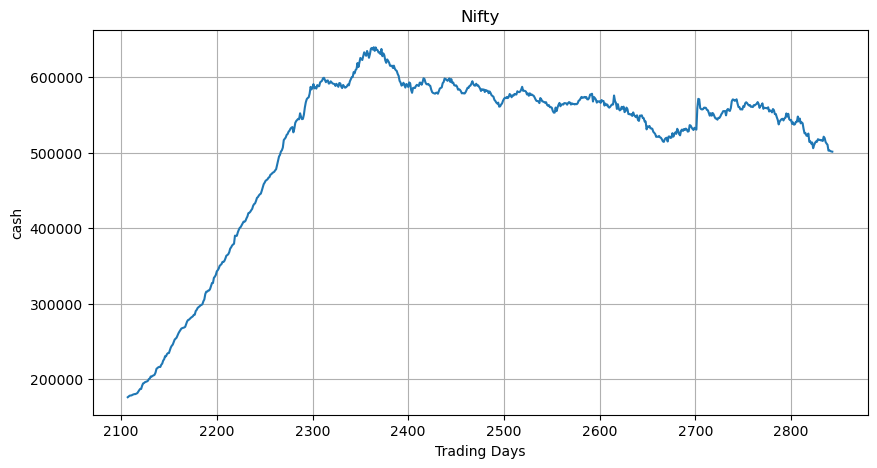

In [19]:
%matplotlib inline
#%pylab inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-1,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()
#fig.savefig('baroda_close.png')